In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Параметры модели
states = ['E', '5', 'I']
obs_map = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

In [3]:
# Начальные вероятности
pi = np.log([1.0, 0.0, 0.0])

/tmp/ipykernel_1544/1785585532.py:2: RuntimeWarning: divide by zero encountered in log
  pi = np.log([1.0, 0.0, 0.0])


In [4]:
# Матрица переходов
A = np.log([
    [0.9, 0.1, 0.0],  # E->E, E->5, E->I
    [0.0, 0.0, 1.0],  # 5->E, 5->5, 5->I
    [0.0, 0.0, 0.9]   # I->E, I->5, I->I
])

/tmp/ipykernel_1544/2377134573.py:2: RuntimeWarning: divide by zero encountered in log
  A = np.log([


In [5]:
# Матрица эмиссий
B = np.log([
    [0.25, 0.25, 0.25, 0.25],  # E
    [0.05, 0.0, 0.95, 0.0],    # 5
    [0.4, 0.1, 0.1, 0.4]       # I
])

/tmp/ipykernel_1544/1984713882.py:2: RuntimeWarning: divide by zero encountered in log
  B = np.log([


In [6]:
# Наблюдения
obs_seq = "CGT"
obs_idx = [obs_map[ch] for ch in obs_seq]
T = len(obs_idx)

In [21]:
def viterbi_log(obs, pi_log, A_log, B_log):
    '''
    Реализация алгоритма Витерби, в нем мы строим наиболее вероятную последовательность скрытых состояний.
    На каждом шаге алгоритма запоминается максимальный по score путь, который ведет в шаг, а потом
    пцть восстанавливается по сохраненным указателям.
    P.S. Последовательность скрытых состояний совпала с ручной реализацией алгоритма, значит все работает как надо
    '''
    N = len(pi_log)
    T = len(obs)
    delta = np.zeros((N, T))
    psi = np.zeros((N, T), dtype=int)

    for i in range(N):
        delta[i, 0] = pi_log[i] + B_log[i, obs[0]]

    for t in range(1, T):
        for j in range(N):
            tmp = [delta[i, t-1] + A_log[i, j] for i in range(N)]
            best = np.max(tmp)
            delta[j, t] = best + B_log[j, obs[t]]
            psi[j, t] = np.argmax(tmp)

    last_state = np.argmax(delta[:, -1])
    prob = delta[last_state, -1]

    path = [last_state]
    for t in range(T-1, 0, -1):
        last_state = psi[last_state, t]
        path.insert(0, last_state)

    return path, prob

In [10]:
viterbi_path, viterbi_logprob = viterbi_log(obs_idx, pi, A, B)
print("Path states:", [states[i] for i in viterbi_path])
print("Log probability:", viterbi_logprob)
print("Probability:", np.exp(viterbi_logprob))

Path states: ['E', 'E', 'E']
Log probability: -4.369604114675324
Probability: 0.012656250000000004


In [22]:
def forward_log(obs, pi_log, A_log, B_log):
    '''
    Реализация алгоритма Forward - вычисляем полную вероятность последовательности с учетом всех
    возможных скрытых состояний. Суммируем вероятности прихода в состояние на каждом шаге
    '''
    N = len(pi_log)
    T = len(obs)
    alpha = np.zeros((N, T))

    for i in range(N):
        alpha[i, 0] = pi_log[i] + B_log[i, obs[0]]

    for t in range(1, T):
        for j in range(N):
            s = np.logaddexp.reduce([alpha[i, t-1] + A_log[i, j] for i in range(N)])
            alpha[j, t] = s + B_log[j, obs[t]]

    log_lik = np.logaddexp.reduce(alpha[:, -1])
    return alpha, log_lik


In [12]:
alpha, log_lik = forward_log(obs_idx, pi, A, B)
print("Log likelihood:", log_lik)
print("Likelihood:", np.exp(log_lik))

Log likelihood: -3.8096356552497355
Likelihood: 0.022156250000000013


In [23]:
def backward_log(obs, A_log, B_log):
    '''
    Реализация алгоритма Backward - вероятность вычисляется для каждой будущей части наблюдений
    для каждого момента времени. Движемся мы здесь от конца к началу
    '''
    N = len(A_log)
    T = len(obs)
    beta = np.zeros((N, T))

    for i in range(N):
        beta[i, -1] = 0.0  # log(1)

    for t in range(T-2, -1, -1):
        for i in range(N):
            s = np.logaddexp.reduce([A_log[i, j] + B_log[j, obs[t+1]] + beta[j, t+1] for j in range(N)])
            beta[i, t] = s
    return beta

In [14]:
beta = backward_log(obs_idx, A, B)

In [24]:
def posterior_gamma(alpha, beta, log_lik):
    '''
    Реализация алгоритма постериорного декодирования - объединение Forward и Backward, по ходу
    алгоритма вычисляем вероятность нахождения в каждом состоянии в каждый момент времени с учетом
    всей последовательности наблюдений
    '''
    N, T = alpha.shape
    gamma = np.zeros((N, T))
    for t in range(T):
        for i in range(N):
            gamma[i, t] = np.exp(alpha[i, t] + beta[i, t] - log_lik)
    return gamma


In [16]:
gamma = posterior_gamma(alpha, beta, log_lik)

In [17]:
# Для демонстрации сгенерируем случайную длинную последовательность
np.random.seed(42)
long_obs = np.random.choice([0,1,2,3], size=26)
long_obs_str = ''.join(['ACGT'[i] for i in long_obs])
print(long_obs_str)

GTAGGTAAGCGGGGTATTTGCACTTC


In [18]:
alpha_long, log_lik_long = forward_log(long_obs, pi, A, B)
beta_long = backward_log(long_obs, A, B)
gamma_long = posterior_gamma(alpha_long, beta_long, log_lik_long)

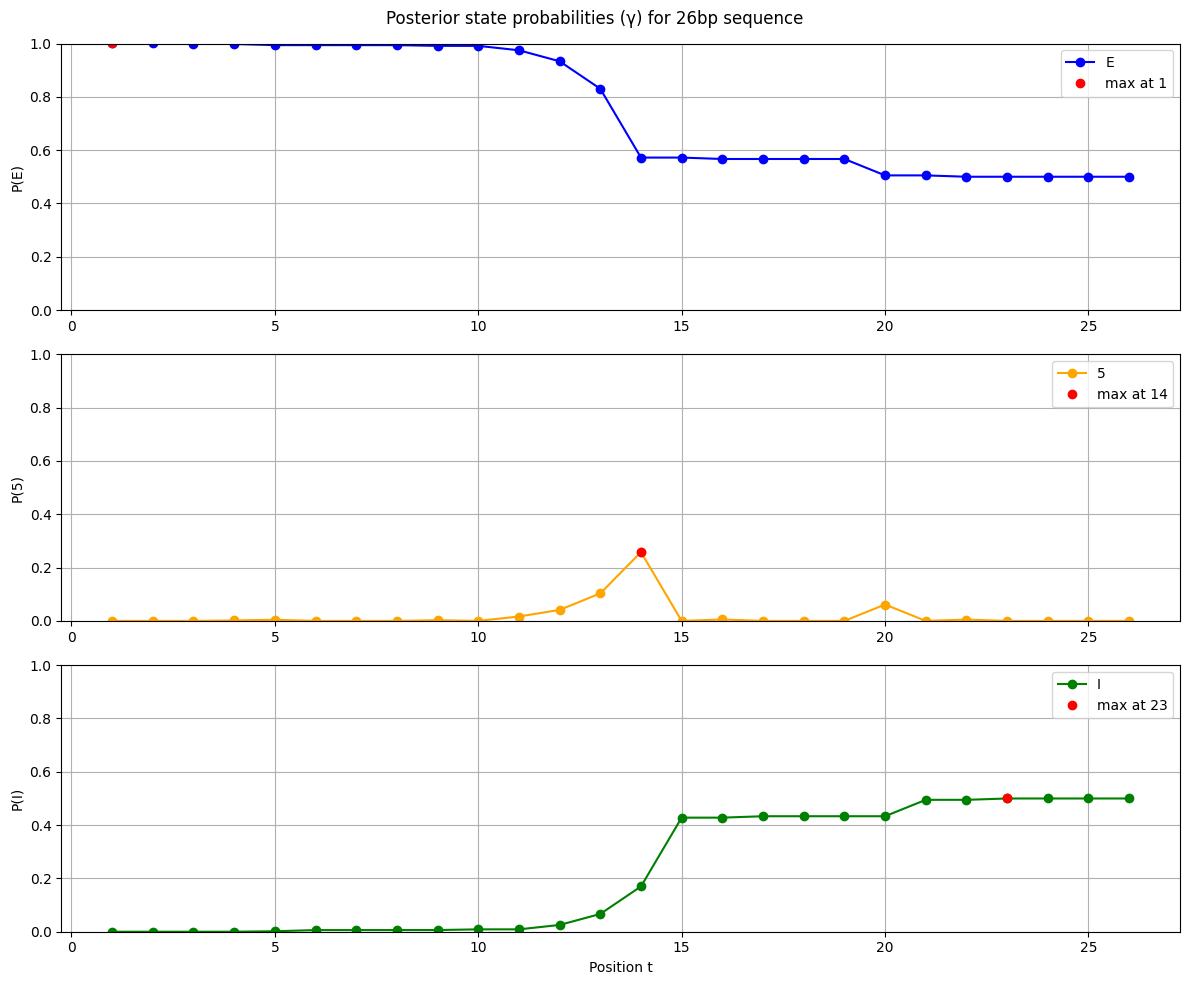

In [19]:
#Визуализируем полученные результаты с помощью графиков
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
state_names = ['E', '5', 'I']
colors = ['blue', 'orange', 'green']

for i, name in enumerate(state_names):
    axes[i].plot(range(1, 27), gamma_long[i, :], label=name, color=colors[i], marker='o')
    max_pos = np.argmax(gamma_long[i, :])
    axes[i].plot(max_pos+1, gamma_long[i, max_pos], 'ro', label=f'max at {max_pos+1}')
    axes[i].set_ylabel(f'P({name})')
    axes[i].set_ylim(0, 1)
    axes[i].legend()
    axes[i].grid(True)

axes[2].set_xlabel('Position t')
plt.suptitle('Posterior state probabilities (γ) for 26bp sequence')
plt.tight_layout()
plt.show()

In [20]:
# А также выведем максимумы апостериорных вероятностей
for i, name in enumerate(state_names):
    max_idx = np.argmax(gamma_long[i, :])
    print(f"{name}: max at t={max_idx+1}, value={gamma_long[i, max_idx]:.4f}")

E: max at t=1, value=1.0000
5: max at t=14, value=0.2580
I: max at t=23, value=0.4998
